<div style="padding:24px;border-left:8px solid #C99700;background:#071B33;color:white;border-radius:8px">
<h1 style="margin:0">Lab 06 · Implied Volatility, State Prices, and Static Arbitrage</h1>
<p style="font-size:17px;margin-bottom:0">An option surface is treated as a system of economic inequalities—not a decorative smile.</p>
</div>

**Research question.** How does a non-lognormal risk-neutral distribution generate an implied-volatility smile, and how can a small quote error imply negative state prices?

**Design.** An arbitrage-free mixture of Black–Scholes economies provides controlled prices. One contaminated quote creates a failure mode; constrained projection repairs the cross section.

## 1. Price-space restrictions come before volatility inversion

For fixed maturity and no dividends, a European call must satisfy

$$\max(0,S_0-Ke^{-rT})\le C(K,T)\le S_0,$$
$$\frac{\partial C}{\partial K}\le0,\qquad \frac{\partial^2 C}{\partial K^2}\ge0.$$

The last inequality rules out butterfly arbitrage. Under regularity, Breeden–Litzenberger gives

$$f_Q(K)=e^{rT}\frac{\partial^2 C(K,T)}{\partial K^2}.$$

Thus negative curvature is not merely an ugly spline: it represents a negative risk-neutral state-price density.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, minimize_scalar

def find_root():
    here=Path.cwd().resolve()
    for candidate in (here,*here.parents):
        if (candidate/'utils'/'quant_models.py').exists(): return candidate
    raise FileNotFoundError('Repository root not found')

ROOT=find_root(); sys.path.insert(0,str(ROOT))
from utils.quant_models import black_scholes_call, black_scholes_greeks, implied_volatility_call

plt.style.use('seaborn-v0_8-whitegrid')
NAVY,BLUE,GOLD,RED,GREEN='#071B33','#1676B8','#C99700','#C84C4C','#26866A'
pd.options.display.float_format='{:,.6f}'.format
S0,r,T=100.0,.02,.75
strikes=np.arange(60.,142.,2.)
print(f'{len(strikes)} strikes | forward = {S0*np.exp(r*T):.4f} | maturity = {T:.2f} years')

41 strikes | forward = 101.5113 | maturity = 0.75 years


## 2. A smile without stochastic volatility

Consider a risk-neutral mixture: with probability $p$, terminal stock follows a low-volatility lognormal law; otherwise it follows a high-volatility lognormal law. Each component has the same forward, so the mixture respects the martingale restriction.

$$C_{mix}(K)=pC_{BS}(K,\sigma_L)+(1-p)C_{BS}(K,\sigma_H).$$

The distribution is not lognormal, so no single Black–Scholes volatility fits every strike. Implied volatility is the strike-specific parameter that reproduces each price—not the literal volatility of one universal GBM.

,mixture_price,implied_vol,flat_vol_price,flat_model_error
strike,,,,
60.000000,41.094736,0.311832,40.898167,-0.196569
70.000000,31.567858,0.277841,31.128248,-0.439610
80.000000,22.303163,0.237490,21.803397,-0.499767
90.000000,13.713679,0.201111,13.724237,0.010558
100.000000,7.139914,0.185897,7.671784,0.531870
110.000000,3.530158,0.192655,3.814664,0.284507
120.000000,2.015533,0.214306,1.705114,-0.310419
130.000000,1.352207,0.240551,0.695087,-0.657119
140.000000,0.964972,0.263868,0.262298,-0.702675


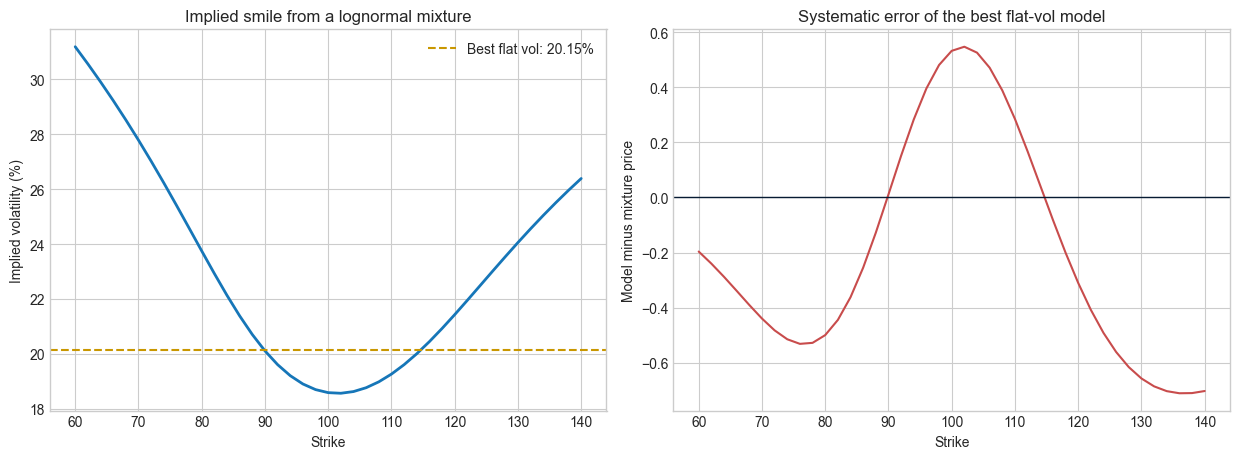

In [2]:
weight,sigma_low,sigma_high=.78,.12,.42
prices=np.array([weight*black_scholes_call(S0,k,T,r,sigma_low)
                 +(1-weight)*black_scholes_call(S0,k,T,r,sigma_high) for k in strikes])
implied=np.array([implied_volatility_call(c,S0,k,T,r) for c,k in zip(prices,strikes)])

flat=minimize_scalar(lambda vol: np.mean([(black_scholes_call(S0,k,T,r,vol)-c)**2
                                          for k,c in zip(strikes,prices)]),bounds=(.01,1),method='bounded')
flat_prices=np.array([black_scholes_call(S0,k,T,r,flat.x) for k in strikes])
surface=pd.DataFrame({'strike':strikes,'mixture_price':prices,'implied_vol':implied,
                      'flat_vol_price':flat_prices,'flat_model_error':flat_prices-prices}).set_index('strike')
display(surface.iloc[::5])

fig,axes=plt.subplots(1,2,figsize=(12.5,4.7))
axes[0].plot(strikes,100*implied,color=BLUE,linewidth=2)
axes[0].axhline(100*flat.x,color=GOLD,linestyle='--',label=f'Best flat vol: {flat.x:.2%}')
axes[0].set(title='Implied smile from a lognormal mixture',xlabel='Strike',ylabel='Implied volatility (%)'); axes[0].legend(frameon=False)
axes[1].plot(strikes,flat_prices-prices,color=RED)
axes[1].axhline(0,color=NAVY,linewidth=1)
axes[1].set(title='Systematic error of the best flat-vol model',xlabel='Strike',ylabel='Model minus mixture price')
plt.tight_layout(); plt.show()

## 3. Static-arbitrage audit and contaminated quote

On an equally spaced strike grid, decreasing calls require $C_i-C_{i+1}\ge0$ and convexity requires $C_{i-1}-2C_i+C_{i+1}\ge0$. A local mid-quote error can respect individual call bounds while violating the joint butterfly condition.

In [3]:
def audit(call_prices):
    intrinsic=np.maximum(0,S0-strikes*np.exp(-r*T))
    slopes=np.diff(call_prices)/np.diff(strikes)
    curvature=np.diff(slopes)/np.diff(strikes[:-1])
    return pd.Series({
        'lower_bound_violations':int(np.sum(call_prices<intrinsic-1e-10)),
        'upper_bound_violations':int(np.sum(call_prices>S0+1e-10)),
        'monotonicity_violations':int(np.sum(slopes>1e-10)),
        'convexity_violations':int(np.sum(curvature<-1e-10)),
        'minimum_discrete_curvature':curvature.min()
    })

contaminated=prices.copy()
bad_index=np.where(strikes==100)[0][0]
contaminated[bad_index]+=1.25
audit_table=pd.DataFrame({'Arbitrage-free mixture':audit(prices),
                          'One contaminated quote':audit(contaminated)})
display(audit_table)
local=pd.DataFrame({'valid':prices,'contaminated':contaminated},index=strikes).loc[94:106]
display(local)

,Arbitrage-free mixture,One contaminated quote
lower_bound_violations,0.000000,0.000000
upper_bound_violations,0.000000,0.000000
monotonicity_violations,0.000000,1.000000
convexity_violations,0.000000,1.000000
minimum_discrete_curvature,0.001254,-0.593365


,valid,contaminated
94.000000,10.750784,10.750784
96.000000,9.426325,9.426325
98.000000,8.220696,8.220696
100.000000,7.139914,8.389914
102.000000,6.185670,6.185670
104.000000,5.355370,5.355370
106.000000,4.642617,4.642617


## 4. Convex projection as a transparent repair

We project contaminated prices onto the nearest vector satisfying bounds, monotonicity, and convexity:

$$\min_{\widetilde C}\sum_i(\widetilde C_i-C_i^{obs})^2$$

subject to the linear no-arbitrage inequalities. This is a diagnostic repair, not a complete bid–ask-aware surface calibration.

,Arbitrage-free mixture,One contaminated quote,Convex projection
lower_bound_violations,0.000000,0.000000,0.000000
upper_bound_violations,0.000000,0.000000,0.000000
monotonicity_violations,0.000000,1.000000,0.000000
convexity_violations,0.000000,1.000000,0.000000
minimum_discrete_curvature,0.001254,-0.593365,-0.000000


Root-mean-square quote adjustment: 0.155451


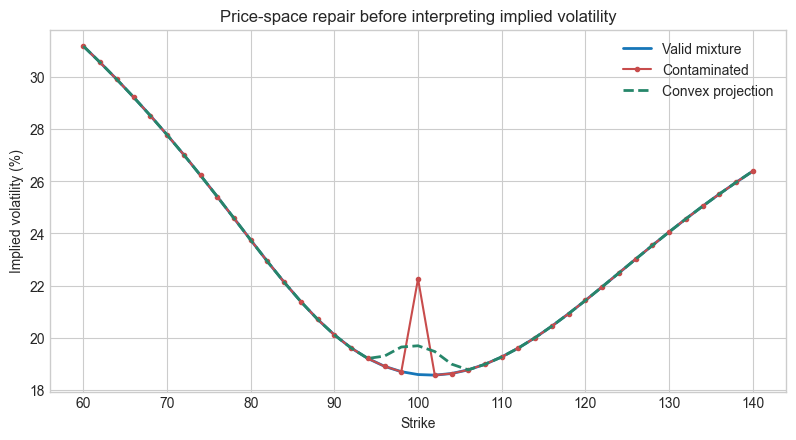

In [4]:
intrinsic=np.maximum(0,S0-strikes*np.exp(-r*T))
constraints=[
    {'type':'ineq','fun':lambda c:c[:-1]-c[1:]},
    {'type':'ineq','fun':lambda c:c[:-2]-2*c[1:-1]+c[2:]},
]
repair=minimize(lambda c:np.sum((c-contaminated)**2),contaminated,method='SLSQP',
                bounds=list(zip(intrinsic,np.full(len(strikes),S0))),constraints=constraints,
                options={'ftol':1e-12,'maxiter':2000})
if not repair.success: raise RuntimeError(repair.message)
repaired=repair.x
audit_table['Convex projection']=audit(repaired)
display(audit_table)
print(f'Root-mean-square quote adjustment: {np.sqrt(np.mean((repaired-contaminated)**2)):.6f}')

iv_bad=np.array([implied_volatility_call(c,S0,k,T,r) for c,k in zip(contaminated,strikes)])
iv_repaired=np.array([implied_volatility_call(c,S0,k,T,r) for c,k in zip(repaired,strikes)])
fig,ax=plt.subplots(figsize=(9.5,4.7))
ax.plot(strikes,100*implied,label='Valid mixture',color=BLUE,linewidth=2)
ax.plot(strikes,100*iv_bad,'o-',label='Contaminated',color=RED,markersize=3)
ax.plot(strikes,100*iv_repaired,'--',label='Convex projection',color=GREEN,linewidth=2)
ax.set(title='Price-space repair before interpreting implied volatility',xlabel='Strike',ylabel='Implied volatility (%)')
ax.legend(frameon=False); plt.show()

## 5. Recovering the risk-neutral density

Finite differences approximate $\partial^2C/\partial K^2$. Differentiation amplifies quote noise, so the density is much less stable than option prices. We report integrated mass on the finite strike grid and negative mass as numerical diagnostics.

C:\Users\badre\AppData\Local\Temp\ipykernel_31676\1840598511.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  diagnostics.append({'surface':name,'grid_probability_mass':np.trapz(density,strikes),
C:\Users\badre\AppData\Local\Temp\ipykernel_31676\1840598511.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  'negative_density_mass':np.trapz(np.minimum(density,0),strikes),


,grid_probability_mass,negative_density_mass,minimum_density
surface,,,
Valid mixture,0.942105,0.000000,0.000636
Contaminated,0.942105,-0.253541,-0.126771
Repaired,0.942105,0.000000,0.000000


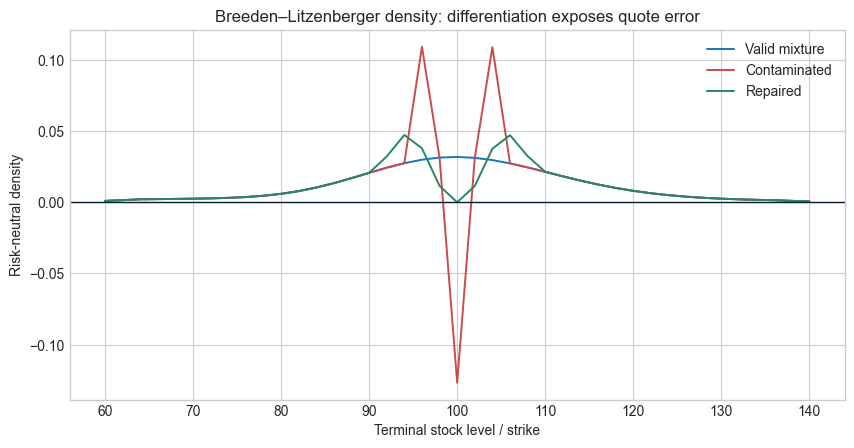

In [5]:
def density_from_calls(call_prices):
    first=np.gradient(call_prices,strikes)
    second=np.gradient(first,strikes)
    return np.exp(r*T)*second

densities=pd.DataFrame({
    'Valid mixture':density_from_calls(prices),
    'Contaminated':density_from_calls(contaminated),
    'Repaired':density_from_calls(repaired)
},index=strikes)
diagnostics=[]
for name,density in densities.items():
    diagnostics.append({'surface':name,'grid_probability_mass':np.trapz(density,strikes),
                        'negative_density_mass':np.trapz(np.minimum(density,0),strikes),
                        'minimum_density':density.min()})
display(pd.DataFrame(diagnostics).set_index('surface'))

ax=densities.plot(figsize=(10,4.8),color=[BLUE,RED,GREEN],linewidth=1.4)
ax.axhline(0,color=NAVY,linewidth=1)
ax.set(title='Breeden–Litzenberger density: differentiation exposes quote error',xlabel='Terminal stock level / strike',ylabel='Risk-neutral density')
plt.show()

## 6. Greek implementation audit

Analytic Greeks should agree with central finite differences as the step becomes small—but not so small that floating-point cancellation dominates. This is a software validation, not evidence that Black–Scholes Greeks hedge the mixture economy.

In [6]:
k0=100.; vol0=float(implied[strikes==k0][0]); hS=.01; hv=1e-5
greeks=black_scholes_greeks(S0,k0,T,r,vol0)
c0=black_scholes_call(S0,k0,T,r,vol0)
cup=black_scholes_call(S0+hS,k0,T,r,vol0); cdn=black_scholes_call(S0-hS,k0,T,r,vol0)
finite_delta=(cup-cdn)/(2*hS)
finite_gamma=(cup-2*c0+cdn)/hS**2
finite_vega=(black_scholes_call(S0,k0,T,r,vol0+hv)-black_scholes_call(S0,k0,T,r,vol0-hv))/(2*hv)
greek_audit=pd.DataFrame({
    'analytic':[greeks['delta'],greeks['gamma'],greeks['vega_per_unit']],
    'finite_difference':[finite_delta,finite_gamma,finite_vega]
},index=['delta','gamma','vega_per_unit'])
greek_audit['absolute_error']=(greek_audit.analytic-greek_audit.finite_difference).abs()
display(greek_audit)

,analytic,finite_difference,absolute_error
delta,0.568937,0.568937,0.000000
gamma,0.024409,0.024409,0.000000
vega_per_unit,34.032307,34.032307,0.000000


## 7. Research conclusion and model-risk register

- An implied-volatility smile is a nonlinear re-expression of option prices. It does not by itself identify a unique stochastic-volatility process.
- Static arbitrage is a joint cross-strike property. Individually plausible quotes can imply a negative state-price density.
- Convex projection makes the repair objective and constraints explicit, but production calibration should respect bid–ask intervals, dividends, rates, and calendar constraints.
- Numerical differentiation is ill conditioned; state-price densities require smoothing choices and stability analysis.

> **Boundary of the evidence.** This is one maturity with deterministic rates and no dividends. A complete surface must also satisfy calendar-spread restrictions and use forward-consistent conventions.

### Extensions

1. Add multiple maturities and enforce total-variance calendar monotonicity.
2. Calibrate SVI in price space with explicit butterfly-arbitrage diagnostics.
3. Infer density uncertainty from bid–ask intervals rather than mid-prices alone.
4. Compare local-volatility and stochastic-volatility dynamics that fit the same initial surface.